# SKU Rationalization and Catalog Productivity
### Iowa Liquor Sales — Trailing 12 Weeks to Dec 2025

## Business Question

Which SKUs are driving the Iowa liquor market — and which are consuming shelf space and working capital with minimal return?

In any mature retail category, a small fraction of the active catalog drives the vast majority of volume and revenue. But the degree of concentration, the categories where bloat is worst, and the SKUs that require individual judgment rather than systematic rules — these are not visible without looking beneath the aggregate.

This analysis classifies the active SKU catalog using a dual-dimension Pareto framework — volume and revenue independently — then examines where the two dimensions align and where they diverge. The divergence is where the most interesting planning decisions live.

## Analytical Approach

- **Pareto tier classification** — Core (top 80%), Niche (next 15%), Zombie (bottom 5%) across both volume and revenue
- **Tier alignment matrix** — where volume and revenue tiers agree and where they diverge at the SKU level
- **Category family breakdown** — whether catalog bloat is uniform or concentrated in specific categories
- **Item-level detail** — the specific SKUs in the most analytically complex cells of the matrix

## System Notes
- Update `params` in Cell 4 to change the analysis window
- `month_start` sets the anchor date. `trailing_weeks` controls the lookback window (default 12 weeks)
- SQL lives in `analysis/sql/`
- Chart logic lives in `analysis/python/charts.py`
- Helpers live in `analysis/python/notebook_helpers.py`

In [730]:
from pathlib import Path
import importlib
import sys
import pandas as pd
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
project_root = next((p for p in [cwd, *cwd.parents] if (p / "dbt_project.yml").exists()), cwd)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from analysis.python import notebook_helpers as nh
from analysis.python import charts
importlib.reload(charts)

<module 'analysis.python.charts' from '/Users/joelam/docs/Data_Science/planning_os/analysis/python/charts.py'>

In [731]:
root = nh.get_project_root(project_root)
engine = nh.get_engine_from_env()

print(f'Project root: {root}')

Project root: /Users/joelam/docs/Data_Science/planning_os


In [732]:
params = {
    # Anchor date for the trailing window. Use YYYY-MM-01 format.
    'month_start': '2025-12-01',

    # Number of trailing weeks to include in the velocity calculation.
    'trailing_weeks': 12,

    # Isolation threshold for auto-labelling points in the full scatter chart.
    # 0–1 scale (fraction of log-axis range). Higher = more labels.
    'isolation_threshold': 0.08,
}

params

{'month_start': '2025-12-01',
 'trailing_weeks': 12,
 'isolation_threshold': 0.08}

## SKU Velocity: The Pareto Principle in Practice

Not all SKUs are created equal. In any mature retail category, 
a small fraction of the active catalog drives the vast majority 
of volume and revenue — while a large portion of SKUs contribute 
almost nothing.

This analysis classifies the active SKU catalog into three tiers:
- **Core (Tier 1)** — top 80% of volume or revenue
- **Niche (Tier 2)** — next 15%
- **Zombie (Tier 3)** — bottom 5%

The key question is not just where volume is concentrated — 
but what share of physical shelf space and working capital the 
Zombie tier consumes relative to the return it delivers.

Tiers are defined independently across two dimensions: volume 
and revenue. A SKU must earn its place on both lenses — 
concentration on one does not guarantee productivity on the other.

In [733]:
tier_summary_sql_template = nh.read_sql(root, 'analysis/sql/sku_velocity_tier_summary.sql')
tier_summary_sql = nh.render_sql(
    tier_summary_sql_template,
    month_start=params['month_start'],
    trailing_weeks=params['trailing_weeks'],
)

df_tier_summary = nh.run_sql(engine, tier_summary_sql)

### Volume Distribution by Tier

Volume is the operational lens — how many bottles are moving 
through the system. The volume distribution establishes where 
unit demand is concentrated and how much of the active catalog 
is generating meaningful movement versus sitting largely dormant.

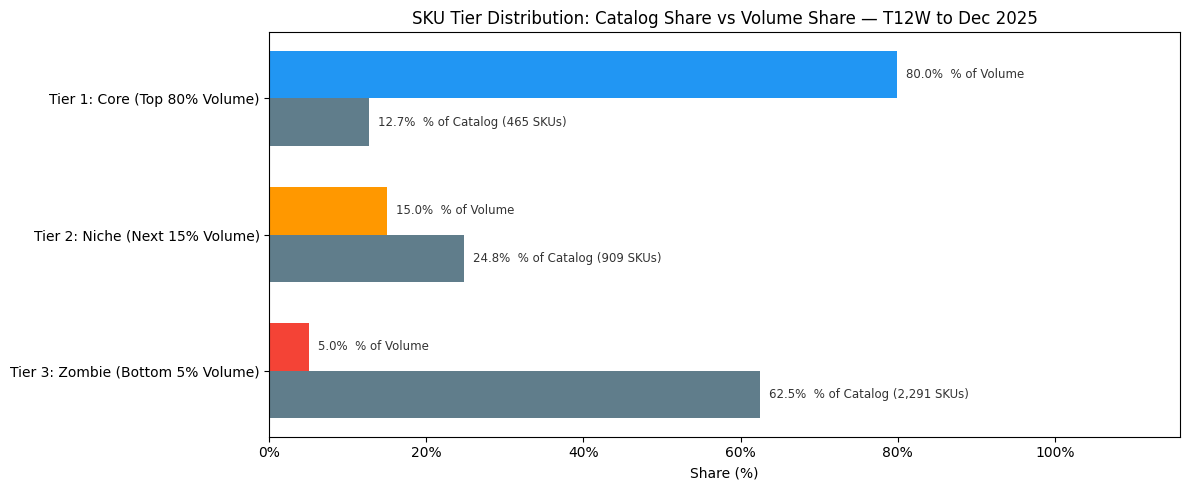

In [734]:
charts.plot_sku_tier_chart(
    df_tier_summary,
    dimension='volume',
    month_start=params['month_start'],
    trailing_weeks=params['trailing_weeks'],
)

### Revenue Distribution by Tier

The revenue view is the more commercially relevant lens. A SKU that moves low volume at high price may still earn its place on the shelf. The Zombie Tax on revenue reveals how much revenue the long tail is actually generating relative to the catalog real estate it occupies.

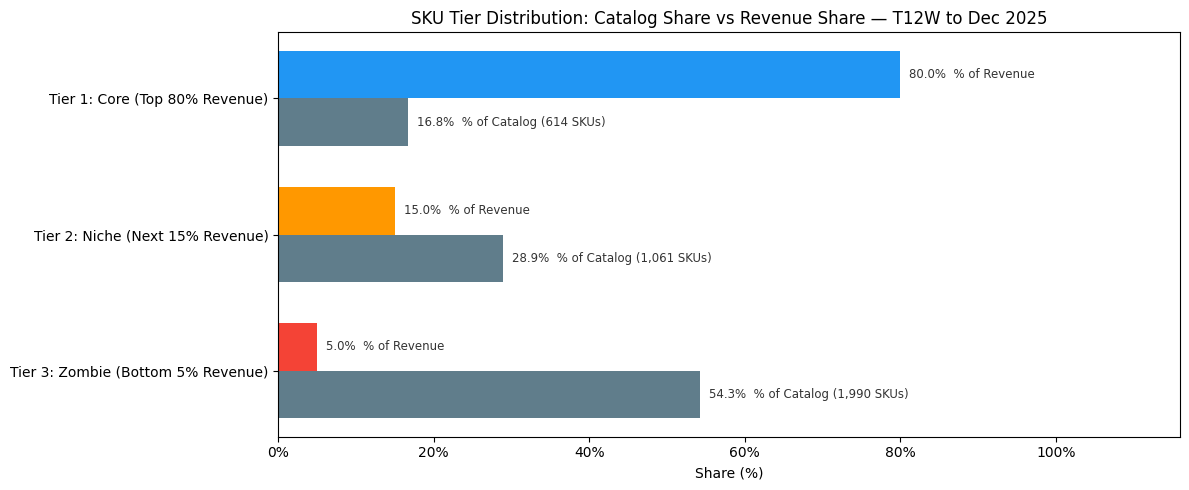

In [735]:
charts.plot_sku_tier_chart(
    df_tier_summary,
    dimension='revenue',
    month_start=params['month_start'],
    trailing_weeks=params['trailing_weeks'],
)

## Interpretation

The two charts together tell a consistent story:

**Catalog bloat is structural, not marginal.** The Zombie tier — bottom 5% of volume and revenue — accounts for roughly 55–60% of the active SKU catalog. These are not edge cases. They are the majority of the product list by count.

**The Core is disproportionately productive.** Approximately 14–16% of active SKUs drive 80% of both volume and revenue. That concentration is stable across both dimensions, which suggests the tier structure is not an artifact of how the tiers are defined — it reflects genuine demand concentration.

**Volume and revenue tiers are not identical.** Some SKUs rank differently on volume vs. revenue — typically high-price, low-velocity items that appear in the Niche or Zombie volume tier but generate meaningful revenue. This divergence is worth examining at the item level when evaluating ranging decisions.

### Operational Implication

The Zombie tier represents the inventory carrying cost, ranging complexity, and working capital tied up in SKUs that collectively move less than 5% of the market. In a capital-constrained retail environment, rationalizing the Zombie tier — or enforcing a velocity threshold for new SKU listings — is one of the highest-leverage levers available to a category manager.

In [736]:
tier_matrix_sql_template = nh.read_sql(root, 'analysis/sql/sku_velocity_tier_matrix.sql')
tier_matrix_sql = nh.render_sql(
    tier_matrix_sql_template,
    month_start=params['month_start'],
    trailing_weeks=params['trailing_weeks'],
)

df_tier_matrix = nh.run_sql(engine, tier_matrix_sql)

## SKU Tier Alignment: Volume vs. Revenue

The volume and revenue charts show how sales distribute across 
tiers independently. But a SKU can rank differently on each 
dimension — and that divergence is where the most interesting 
planning decisions live.

A high-price, low-velocity item may rank Core on revenue but 
Zombie on volume — it earns its place through margin, not 
movement. The inverse is also possible: a high-volume, low-price 
SKU that ranks Core on volume but contributes almost nothing 
on revenue.

This matrix maps every active SKU across both dimensions 
simultaneously. Diagonal cells are aligned — the tier is 
consistent across both lenses. Off-diagonal cells are where 
individual evaluation is warranted before making ranging or 
rationalization decisions.

### Key Question
Are the SKUs driving volume the same ones driving revenue — 
and what does the divergence tell us about catalog risk and 
planning complexity?

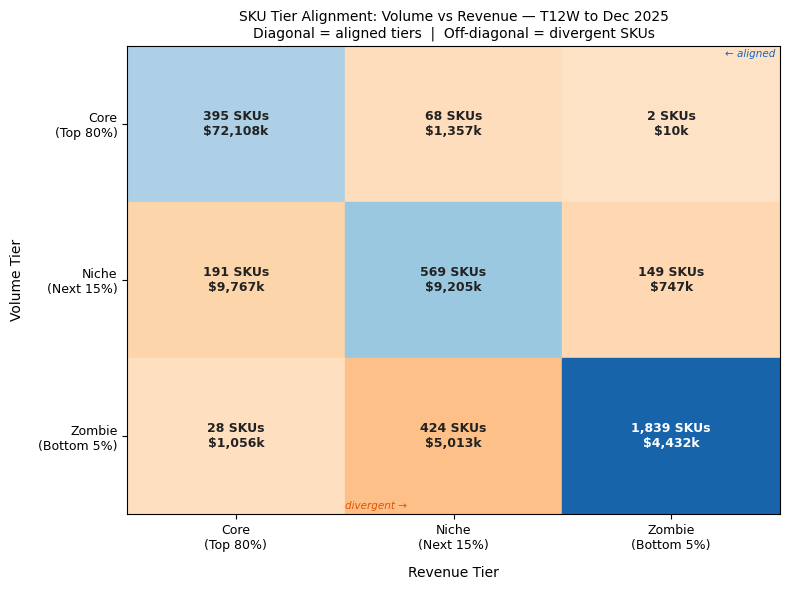

In [737]:
charts.plot_sku_tier_matrix(
    df_tier_matrix,
    month_start=params['month_start'],
    trailing_weeks=params['trailing_weeks'],
)

### Findings

**The diagonal tells the expected story.**
The three aligned cells — Core/Core, Niche/Niche, Zombie/Zombie — confirm 
that volume and revenue are broadly correlated. The 395 Core/Core SKUs are 
the true anchors of the catalog: high velocity, high revenue, stable demand. 
These are the SKUs a category manager protects unconditionally.

The 1,839 Zombie/Zombie SKUs are the clearest rationalization candidates — 
bottom 5% on both dimensions. They represent the structural catalog bloat 
identified in the volume and revenue charts: a large share of active SKUs 
consuming shelf space and working capital with minimal commercial return.

**The off-diagonal tells the more interesting story.**

*28 SKUs: Core revenue, Zombie volume.*

These SKUs earn their revenue tier through price, not movement — but 
they are not a homogeneous group. The item-level data reveals three 
distinct planning archetypes that require different management responses.

**Collector and ultra-premium expressions.**
Johnnie Walker Blue ($169 ASP), Four Roses Limited Edition ($200 ASP), 
Hennessy XO ($150 ASP), Macallan 12yr ($75 ASP), and similar items sell 
infrequently but at significant price points. Their revenue contribution 
is real but structurally fragile — concentrated in very few transactions. 
A single missed sale or an out-of-stock event can push these SKUs out of 
the Core revenue tier entirely. Standard velocity-based replenishment does 
not apply. These items require exception-based management: event-driven 
reordering, close cycle monitoring, and ranging decisions that account for 
demand fragility rather than treating them as equivalent to high-velocity 
Core SKUs.

**Limited and seasonal releases.**
Field of Dreams All Star Whiskey, Jack Daniels Sinatra, High West 
Midwinter Nights Dram, Don Julio Tri Pack, and similar items are 
time-bound by design. Their Zombie volume status partly reflects the 
12-week trailing window capturing them outside their peak demand period — 
in a different window they would look materially different. A trailing 
12-week view can misclassify seasonal SKUs as low-performers when they 
are actually high-performers in a compressed window. These items warrant 
longer-horizon evaluation before ranging decisions are made.

**Mini variety packs at bulk pricing.**
Several 99 Brand mini variety packs, Fireball Window Box Minis, and 
similar items appear in this group with ASPs around $81 — not because 
they are premium items, but because they are sold in bulk pack formats 
where a single wholesale transaction represents a large case quantity at 
a high per-transaction price. Their Zombie volume status is partly a 
data artifact of the wholesale sell-in grain: one bulk order registers 
as a single unit at an elevated price. These items are not fragile 
premium SKUs — they are high-velocity consumer products that move 
through a different transaction structure at the wholesale level.

### Implication

The Core revenue / Zombie volume cell is the most analytically complex 
in the matrix. A category manager treating all 28 SKUs as equivalent 
would apply the wrong management framework to most of them:

- Collector items need exception-based ranging protection
- Seasonal releases need window-aware evaluation before any 
  rationalization decision
- Mini variety packs need grain-aware interpretation before 
  their velocity is judged

This is where the dual-dimension model earns its value — not by 
producing a clean answer, but by surfacing the SKUs that require 
individual judgment rather than systematic rules.

### Item-Level Detail: Core Revenue / Zombie Volume SKUs

The 28 SKUs in this cell span a wider range than the tier classification suggests. The table below shows the full list — sorted by revenue — with ASP and unit count visible. The three planning archetypes described above are all present.

In [738]:
divergent_sql_template = nh.read_sql(root, 'analysis/sql/sku_velocity_tier_divergent.sql')
divergent_sql = nh.render_sql(
    divergent_sql_template,
    month_start=params['month_start'],
    trailing_weeks=params['trailing_weeks'],
    volume_tier_filter='Tier 3: Zombie',
    revenue_tier_filter='Tier 1: Core',
)

df_divergent = nh.run_sql(engine, divergent_sql)

In [739]:
charts.display_sku_table(df_divergent)

Item,Category Family,Category,ASP ($),Revenue ($),Units Sold,Volume Tier,Revenue Tier
JOHNNIE WALKER BLUE,Whiskies,SCOTCH WHISKIES,168.74,"55,178",327,Tier 3: Zombie,Tier 1: Core
THE ORIGINAL PICKLE SHOT DILL PICKLE VODKA MINI,Vodkas,AMERICAN FLAVORED VODKA,143.40,"51,768",361,Tier 3: Zombie,Tier 1: Core
WOODFORD RESERVE BARREL STRENGTH RYE BARREL PROOF,Whiskies,STRAIGHT RYE WHISKIES,101.39,"49,985",493,Tier 3: Zombie,Tier 1: Core
TEMPLETON RYE 13 YEAR HIDDEN STASH,Specialty/Other Spirits,TEMPORARY & SPECIALTY PACKAGES,127.50,"47,302",371,Tier 3: Zombie,Tier 1: Core
99 CHERRIES MINI,Liqueurs,AMERICAN SCHNAPPS,81.00,"43,659",539,Tier 3: Zombie,Tier 1: Core
HENNESSY XO GB UPGRADE,Brandies,IMPORTED BRANDIES,149.99,"43,497",290,Tier 3: Zombie,Tier 1: Core
FIELD OF DREAMS ALL STAR WHISKEY,Specialty/Other Spirits,TEMPORARY & SPECIALTY PACKAGES,74.25,"39,204",528,Tier 3: Zombie,Tier 1: Core
JACK DANIELS SINATRA,Specialty/Other Spirits,TEMPORARY & SPECIALTY PACKAGES,136.58,"39,062",286,Tier 3: Zombie,Tier 1: Core
FIREBALL BLAZIN APPLE CANDY CANE MINI,Specialty/Other Spirits,TEMPORARY & SPECIALTY PACKAGES,78.48,"39,005",497,Tier 3: Zombie,Tier 1: Core
99 PUNCHES VARIETY MINI,Liqueurs,AMERICAN SCHNAPPS,81.00,"37,341",461,Tier 3: Zombie,Tier 1: Core


### Visualizing the Three Archetypes

The table above shows the full list. The scatter below shows the structural difference between the three planning archetypes visually — dot size reflects average selling price, color reflects archetype classification.

The upper left cluster — low units, high revenue, large dots — are the collector and ultra-premium items. The lower right cluster — higher units, moderate revenue, smaller dots — are the mini variety packs where bulk pricing inflates the per-transaction price. The seasonal and limited release items sit between both clusters, reflecting their time-bound demand pattern rather than a stable positioning.

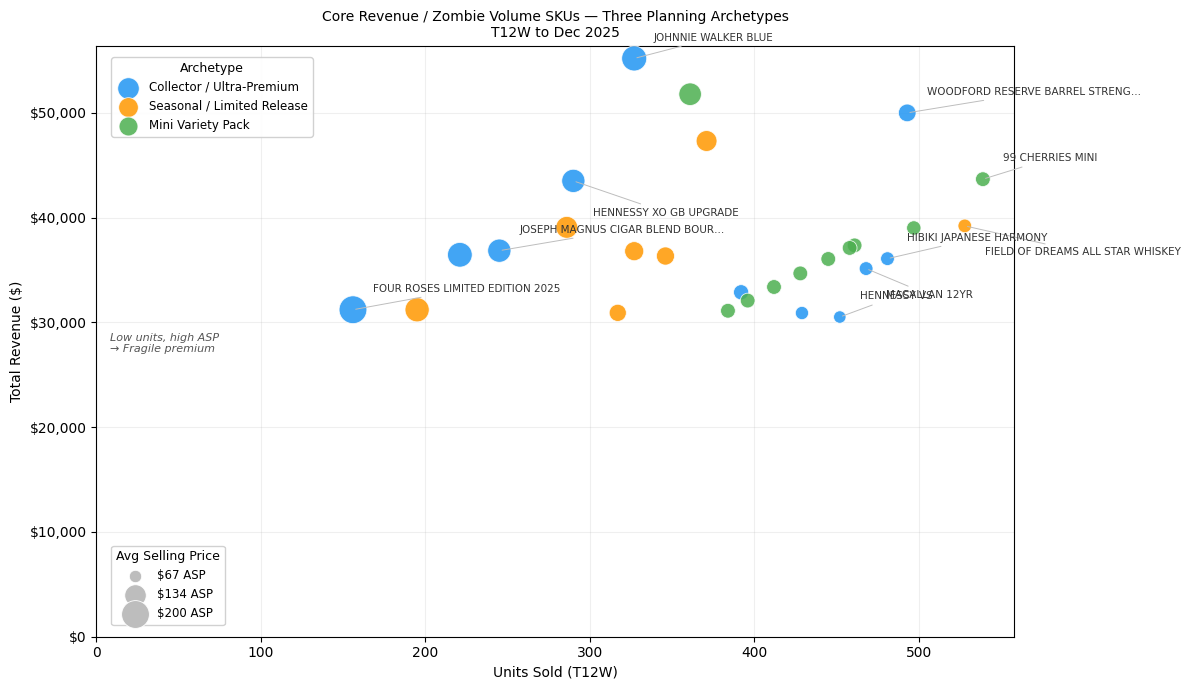

In [740]:
charts.plot_sku_archetype_scatter(
    df_divergent,
    params['month_start'],
    params['trailing_weeks'],
)

### High-Volume, Low-Revenue SKUs: Core Volume, Zombie Revenue

The inverse case: 2 SKUs in the top 80% of volume but the 
bottom 5% of revenue.

The item-level data confirms exactly what the classification 
suggests — E&J VS Pet and 99 Cinnamon, both at a $1.50 average 
selling price. These are 50ml mini format items sold individually 
or in small multipacks, moving thousands of units at near-zero 
revenue per transaction.

They earn their ranging position on velocity grounds — high 
unit movement signals genuine consumer demand. But their 
commercial contribution is negligible relative to the shelf 
space and working capital they require. At $1.50 per unit, 
even 4,000 bottles generates less than $6,000 in revenue over 
a trailing 12-week window.

These are not rationalization candidates on velocity grounds. 
They are candidates for a different kind of evaluation: whether 
the operational cost of carrying and replenishing a very 
low-price, high-movement SKU is justified by the margin it 
actually contributes — not just the units it moves.

The table below confirms the item-level detail.

In [741]:
divergent_inverse_sql = nh.render_sql(
    divergent_sql_template,
    month_start=params['month_start'],
    trailing_weeks=params['trailing_weeks'],
    volume_tier_filter='Tier 1: Core',
    revenue_tier_filter='Tier 3: Zombie',
)

df_divergent_inverse = nh.run_sql(engine, divergent_inverse_sql)

In [742]:
charts.display_sku_table(df_divergent_inverse)

Item,Category Family,Category,ASP ($),Revenue ($),Units Sold,Volume Tier,Revenue Tier
E & J VS PET,Brandies,AMERICAN BRANDIES,1.50,"5,859","3,906",Tier 1: Core,Tier 3: Zombie
99 CINNAMON,Liqueurs,AMERICAN CORDIALS & LIQUEURS,1.50,"4,107","2,738",Tier 1: Core,Tier 3: Zombie


## Catalog Bloat by Category Family

The statewide analysis shows that roughly 55–60% of all active SKUs sit in the Zombie tier. But that aggregate masks important variation across categories.

Is catalog bloat a market-wide structural condition, or is it concentrated in specific categories — and if so, which ones?

The chart below breaks the tier distribution down by category family, sorted by Zombie share. Tiers are still defined statewide (a SKU is Core if it is in the top 80% of all Iowa sales), so the category-level breakdown reflects each category's contribution to the overall market rather than its internal rank.

In [743]:
tier_by_category_sql_template = nh.read_sql(root, 'analysis/sql/sku_velocity_tier_by_category.sql')
tier_by_category_sql = nh.render_sql(
    tier_by_category_sql_template,
    month_start=params['month_start'],
    trailing_weeks=params['trailing_weeks'],
)

df_tier_by_category = nh.run_sql(engine, tier_by_category_sql)

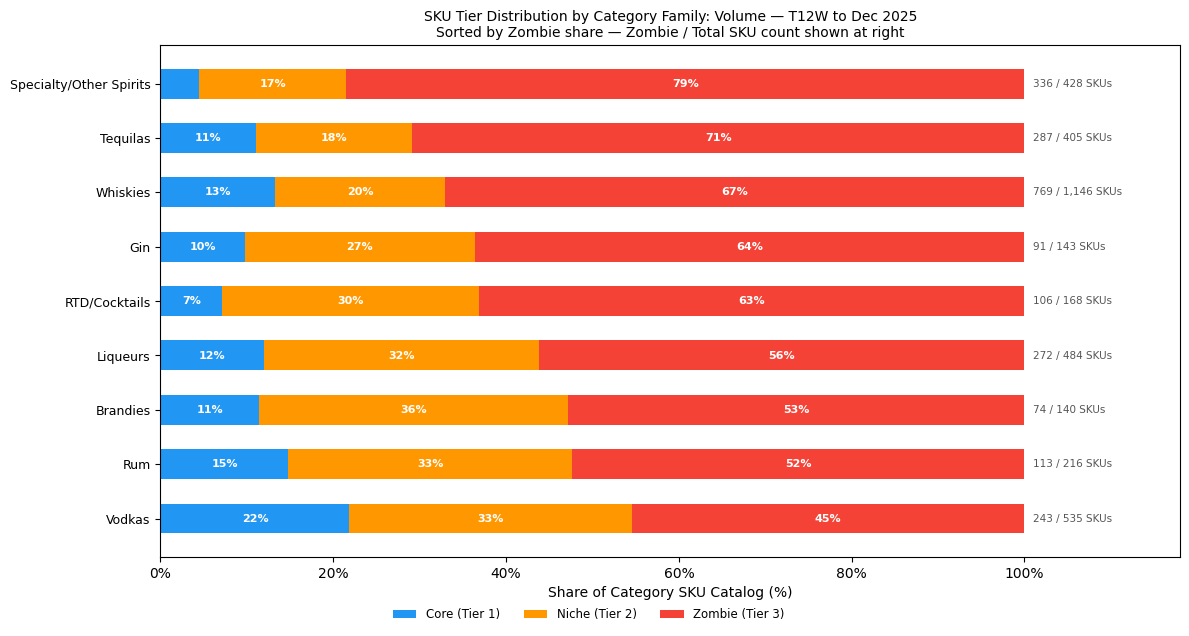

In [744]:
charts.plot_sku_tier_by_category(
    df_tier_by_category,
    dimension='volume',
    month_start=params['month_start'],
    trailing_weeks=params['trailing_weeks'],
)

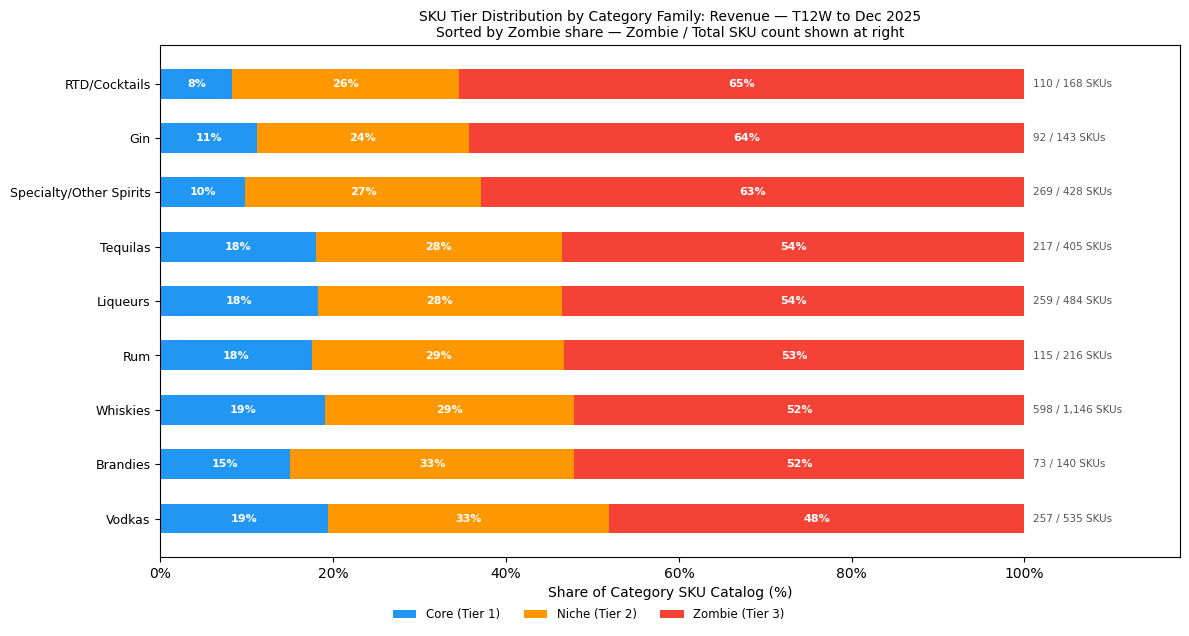

In [745]:
charts.plot_sku_tier_by_category(
    df_tier_by_category,
    dimension='revenue',
    month_start=params['month_start'],
    trailing_weeks=params['trailing_weeks'],
)

### Findings

**Catalog bloat is market-wide — but the severity varies significantly 
by category.**

On volume, Zombie share ranges from 45% in Vodkas to 79% in 
Specialty/Other Spirits. On revenue, the range is 48% to 65%. 
No category escapes the long tail, but the degree of bloat is 
meaningfully different across the shelf.

**Vodkas is the healthiest catalog by both measures.**
With the lowest Zombie share on volume (45%) and revenue (48%) — 
and the highest Core share at 22% and 19% respectively — Vodkas 
shows genuine demand breadth. More SKUs are earning their place 
relative to the rest of the market. Given the category's scale 
(535 active SKUs), that's a meaningful signal: broad consumer 
demand is supporting a larger active assortment.

**Whiskies carries the largest absolute catalog burden.**
At 1,146 active SKUs — the largest catalog in the market — 
Whiskies has 769 SKUs sitting in the Zombie tier on volume. 
The percentage (67%) is not the worst in the market, but the 
absolute scale of low-productivity SKUs is significant. A category 
manager inheriting the Whiskies shelf faces a rationalization 
challenge that is structural in scale, not just marginal.

**Tequilas shows one of the largest gaps between volume and 
revenue Zombie share.**
71% Zombie on volume — but only 54% on revenue. That 17-point 
gap is among the widest in the dataset and reflects a dynamic 
explored in more depth in the category growth analysis: premium 
tequila SKUs generate disproportionate revenue relative to unit 
movement. Many SKUs that rarely sell are still earning their 
place on the shelf through price, not velocity.

**RTD/Cocktails shows the reverse pattern.**
Relatively moderate Zombie share on volume (63%) but the highest 
on revenue (65%). The category has SKUs moving meaningful volume 
that aren't converting to revenue — consistent with RTD being a 
promotional, lower-price-point category where velocity doesn't 
reliably translate to commercial return.

### Implication

Catalog rationalization is not a single market-wide prescription. 
The right threshold — and the right criteria — differ by category:

- In **Vodkas**, the catalog is relatively productive. Rationalization 
  pressure is lower and the focus should be on protecting the breadth 
  that's already earning its place.
- In **Whiskies**, the scale of the Zombie tier makes systematic 
  velocity thresholds for new listings a credible operating lever — 
  not just a cleanup exercise.
- In **Tequilas**, volume-based rationalization alone would 
  remove SKUs that are genuinely contributing revenue. A dual-dimension 
  approach — as modeled in this analysis — is essential before making 
  ranging decisions.
- In **RTD/Cocktails**, the revenue Zombie share suggests the category 
  is carrying promotional SKUs that move units without generating 
  sustainable return. A revenue-first rationalization lens is more 
  appropriate than a volume-first one.

Catalog rationalization is most effective when the criteria reflect 
how each category actually generates value — not when a single 
statewide threshold is applied uniformly across a heterogeneous shelf.

## The Full Catalog View

The bar charts and matrix show how SKUs distribute across 
tiers in aggregate. This scatter shows the underlying 
structure directly — every active SKU in the Iowa liquor 
market plotted by units sold and total revenue simultaneously.

The shape of the distribution is the argument.

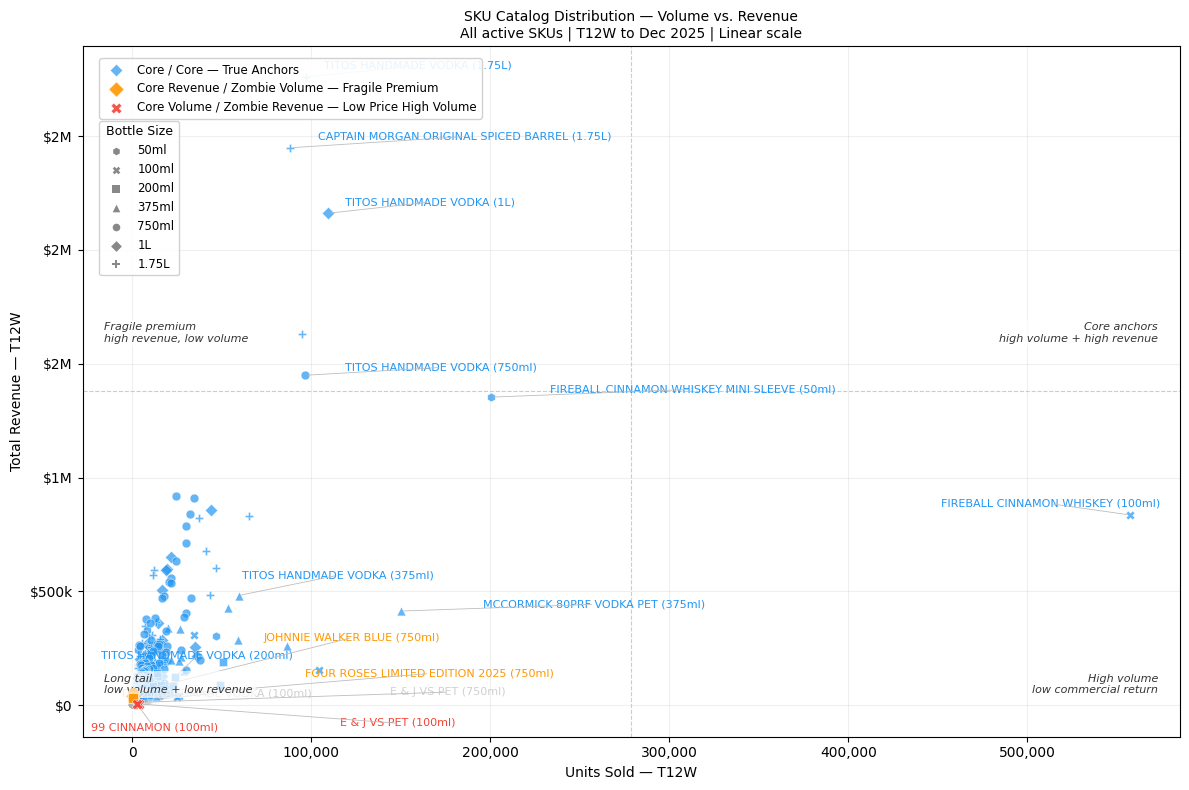

In [746]:
full_scatter_sql_template = nh.read_sql(
    root,
    'analysis/sql/sku_velocity_full_scatter.sql'
)
full_scatter_sql = nh.render_sql(
    full_scatter_sql_template,
    month_start=params['month_start'],
    trailing_weeks=params['trailing_weeks'],
)

df_full_scatter = nh.run_sql(engine, full_scatter_sql)

charts.plot_sku_full_scatter(
    df_full_scatter,
    params['month_start'],
    params['trailing_weeks'],
    log_scale=False,
    isolation_threshold=params['isolation_threshold'],
)

### What the Linear View Reveals

On a linear scale the dominance of the highest-volume SKUs 
is immediate and visceral. Tito's Handmade Vodka — moving 
over 500,000 units in a trailing 12-week window across 
multiple formats — forces the x-axis so far out that the 
vast majority of the catalog compresses into an 
indistinguishable mass near zero.

The highlighted groups disappear into the noise. The catalog 
structure that the tier analysis revealed becomes invisible.

This isn't a data problem. It's a scale problem.

### Why the Scale Matters

The linear view makes the problem visible — but not in the 
way you might expect.

A handful of extremely high-volume SKUs force the axis so 
far out that the vast majority of SKUs compress into an 
indistinguishable mass near zero. The highlighted outliers — 
the fragile premium items and the high-volume low-revenue 
anomalies — disappear into the noise. The catalog structure 
that the tier analysis revealed becomes invisible.

This isn't a data problem. It's a scale problem.

The same data looks completely different when the scale 
is adjusted to match the range of the distribution. Rather 
than fixed increments — 100k, 200k, 300k — the chart below 
uses a scale where each step represents a 10x change. This 
compresses the extremes and expands the middle, making the 
full range of the catalog readable simultaneously.

The structure that was hidden becomes visible.
The long tail separates from the core.
The highlighted groups find their natural positions.

Same data. Different lens.

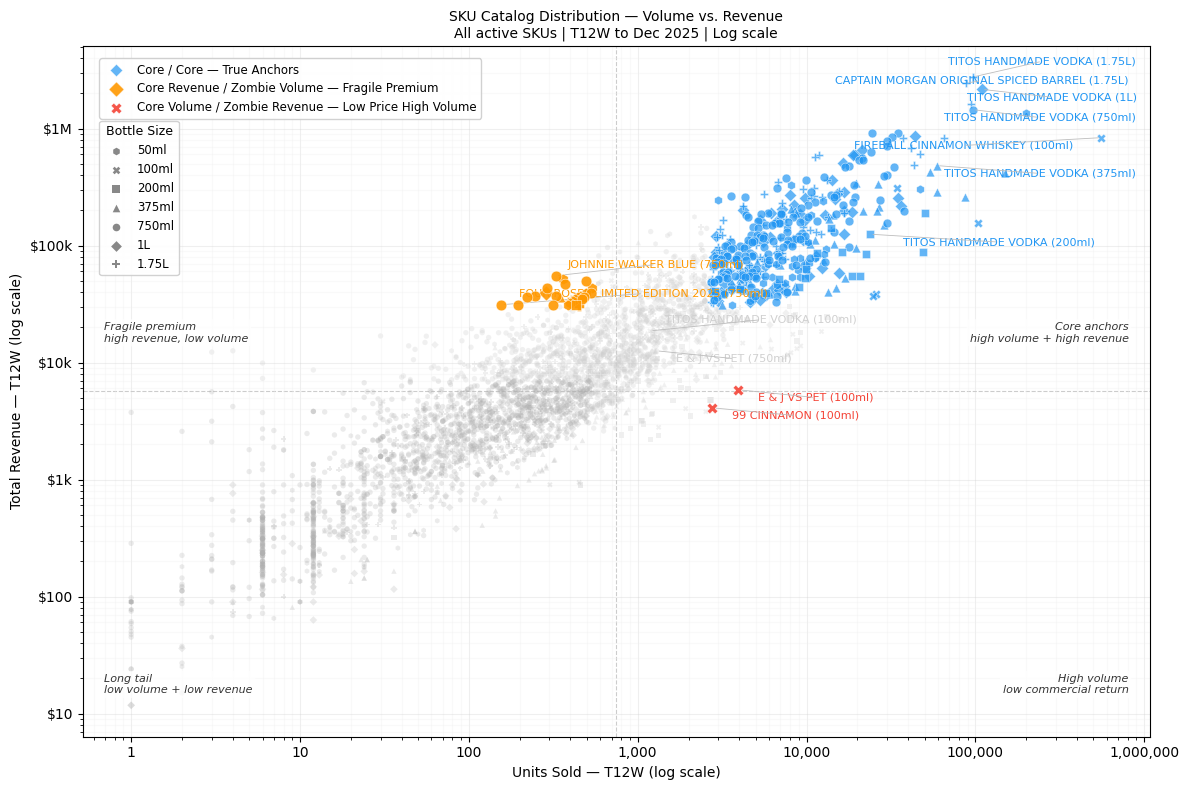

In [747]:
full_scatter_sql_template = nh.read_sql(
    root,
    'analysis/sql/sku_velocity_full_scatter.sql'
)
full_scatter_sql = nh.render_sql(
    full_scatter_sql_template,
    month_start=params['month_start'],
    trailing_weeks=params['trailing_weeks'],
)

df_full_scatter = nh.run_sql(engine, full_scatter_sql)

charts.plot_sku_full_scatter(
    df_full_scatter,
    params['month_start'],
    params['trailing_weeks'],
    log_scale=True,
    isolation_threshold=params['isolation_threshold'],
)

### Findings: Full Catalog

**The shape confirms the Pareto argument.**
The visual gap between the dense gray mass in the lower 
left and the sparse blue cluster in the upper right is 
not subtle. Thousands of SKUs generating minimal volume 
and revenue — separated by a clear discontinuity from the 
small set of anchors driving the market. The tier 
classification didn't create this structure. It revealed 
one that was already there.

**The fragile premium cluster is structurally isolated.**
The orange dots — Core revenue / Zombie volume SKUs — sit 
clearly between the two extremes. Not in the long tail. 
Not in the Core anchor cluster. Their isolation reflects 
exactly what the matrix analysis showed: these SKUs earn 
their revenue tier through price, not movement. Johnnie 
Walker Blue and Four Roses Limited Edition are the most 
visible — high revenue, low units, large bottle format 
markers reflecting their ASP.

**The two red crosses tell a complete story in two points.**
E&J VS Pet and 99 Cinnamon — the Core volume / Zombie 
revenue anomalies — are immediately visible despite 
representing only 2 of 3,000+ active SKUs. High on the 
x-axis, low on the y-axis relative to their unit count. 
Mini format markers. The data artifact of the wholesale 
sell-in grain made visible as a labeled outlier.

**Tito's portfolio depth dominates the Core anchor cluster.**
Multiple Tito's formats — 1.75L, 1L, 750ml, 375ml, 200ml — 
are visible as labeled anchors in the upper right. The same 
brand appearing across five bottle formats in the Core tier 
is the format strategy story made visual: portfolio breadth 
across occasions and price points within a single brand 
identity.

**Fireball Cinnamon Whiskey 100ml is the notable outlier.**
A trial format SKU sitting at anchor-level revenue — 
significantly higher than most 100ml items — reflects 
the brand's unusual position: a flavored whiskey that 
generates Core revenue even in a small format, driven 
by high consumer trial velocity rather than premium pricing.

## Category View: Whiskies

The full catalog view shows the market-wide structure. 
Filtering to a single category family reveals how that 
structure varies — and where catalog rationalization 
pressure is most acute.

Whiskies is the largest category in the Iowa market by 
SKU count — 1,146 active SKUs — and showed a 67% Zombie 
share in the category breakdown analysis. This scatter 
shows what that looks like at the individual SKU level.

### Key Question
Does the Whiskies long tail look structurally different 
from the full market — and who are the true anchors 
holding the category together?

### Category Family View

The same scatter filtered to a single category family. Update `category_family` to explore any category — available values match the `category_family` column in `dim_item` (e.g. `'Whiskies'`, `'Tequilas'`, `'Vodkas'`, `'Rum'`).

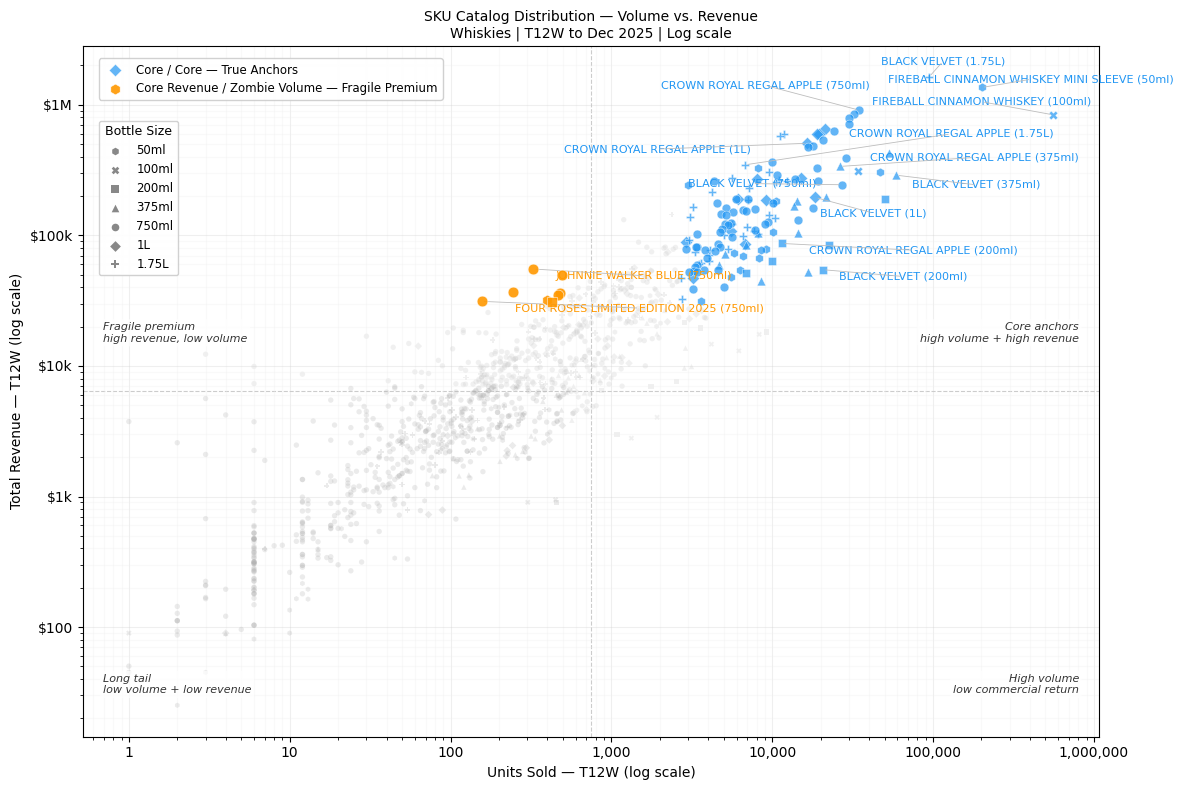

In [748]:
charts.plot_sku_full_scatter(
    df_full_scatter,
    params['month_start'],
    params['trailing_weeks'],
    log_scale=True,
    category_family='Whiskies',
    isolation_threshold=params['isolation_threshold'],
)

### Findings: Whiskies

**The long tail is proportionally larger than the full market.**
The gray mass in the lower left is denser relative to the 
Core anchor cluster than in the full catalog view — 
consistent with the 67% Zombie share finding. More SKUs 
are generating minimal movement relative to the anchors 
that are doing the commercial work. The gap between the 
long tail and the Core cluster is visually more pronounced 
here than in the full market view.

**Crown Royal and Black Velvet anchor the category across formats.**
Crown Royal Regal Apple and Black Velvet dominate the Core 
anchor cluster — each present across multiple bottle formats 
in the upper right quadrant. This is a different brand story 
than Vodkas, where Tito's led with a single brand across 
formats. Whiskies has two brands sharing anchor responsibility, 
each with meaningful format breadth.

**Fireball appears again — now in context.**
Fireball Cinnamon Whiskey and its Mini Sleeve format appear 
prominently in the Core anchor cluster. The Mini Sleeve — 
a 50ml trial format — sitting at anchor-level revenue within 
Whiskies confirms what the full catalog view suggested: 
Fireball's trial format generates unusually high velocity 
relative to its size, earning Core status through frequency 
of purchase rather than transaction value.

**The fragile premium cluster reflects the broader finding.**
Johnnie Walker Blue and Four Roses Limited Edition are 
visible in the Whiskies view — the same items flagged in 
the full catalog matrix analysis. Within the Whiskies 
category they sit even more clearly isolated from the 
Core anchor cluster — high revenue, low units, 
structurally distinct from the brands that anchor the 
category through volume.

**No Core volume / Zombie revenue anomalies in Whiskies.**
Unlike the full catalog view, there are no red crosses here. 
Whiskies has no SKUs in the top 80% of volume but bottom 
5% of revenue. The high-volume, low-price anomaly pattern 
visible in the full market is driven by other categories — 
not Whiskies. This is worth noting: Whiskies' catalog bloat 
problem is in the long tail, not in anomalous high-volume 
low-revenue SKUs.

### Implication

The Whiskies rationalization challenge is structural and 
concentrated in the long tail — 769 Zombie SKUs by count, 
the largest absolute rationalization opportunity in the 
market. The anchors are clear. The long tail is large. 
The path forward is enforcing velocity thresholds for 
new listings rather than protecting existing SKUs that 
have already demonstrated they can't earn their place.

The category breakdown chart showed Whiskies at 67% Zombie 
share. This scatter shows why — not because the anchors 
are weak, but because the long tail is extensive.

## Final Takeaways

The Iowa liquor catalog follows a classic Pareto pattern — but the story is more nuanced than the aggregate numbers suggest.

A small share of active SKUs drives a disproportionate share of both volume and revenue. That concentration is stable across both dimensions, which means it reflects genuine demand structure rather than an artifact of how the tiers are defined.

But catalog bloat is structural, not marginal. Roughly 55–60% of active SKUs sit in the Zombie tier statewide — and that condition is not uniform across categories. Specialty/Other Spirits and Tequilas carry the heaviest Zombie burden on volume. Vodkas is the healthiest catalog by both measures. Whiskies carries the largest absolute rationalization challenge by SKU count.

The tier alignment matrix reveals that the Core tier is not homogeneous. It contains at least two meaningfully different planning archetypes — true anchors with stable, predictable demand, and fragile premium items whose revenue contribution is real but concentrated in very few transactions. Treating them the same in a replenishment or ranging framework would systematically produce the wrong decisions.

The most actionable implication is not a single rationalization threshold. It is a framework:

- Protect Core/Core SKUs unconditionally
- Evaluate Core revenue / Zombie volume SKUs by archetype — collector, seasonal, or format artifact
- Apply category-specific rationalization criteria to the Zombie tier rather than a uniform statewide rule
- Use longer evaluation horizons for seasonal and limited release SKUs before making ranging decisions

---

This analysis is part of a broader planning system built on Python, Snowflake, and dbt. The tier classification logic lives in `fct_sku_velocity` in the mart layer, enabling this analysis to be run for any trailing window without rebuilding the underlying model.